# Desafio Final — ClearBank

Análise de transações bancárias: leitura, validação, métricas mensais e detecção de transações suspeitas.

## Instruções

Antes de executar este notebook, crie o arquivo `transacoes.csv` na raiz do projeto com as colunas:
`id`, `data`, `cliente_id`, `tipo`, `valor`, `descricao`, `categoria`.

O arquivo deve conter:
- Pelo menos **15 registros válidos** distribuídos em **3 ou mais meses**
- **5 registros inválidos** para testar a validação
- Pelo menos **2 transações** com valor acima de R$ 10.000,00

Execute as células em ordem. A célula principal ao final integra todas as funções.

## 1. Configuração e constantes

In [2]:
from __future__ import annotations

import csv
import json
from datetime import datetime
from pathlib import Path

ARQUIVO_CSV = Path("transacoes.csv")
ARQUIVO_JSON = Path("relatorio.json")
LIMITE_SUSPEITO = 10000.00

## 2. Leitura do CSV (módulo nativo)

In [3]:
def ler_transacoes(caminho: Path) -> list[dict]:
    """Lê o CSV e retorna a lista de transações brutas."""
    transacoes = []
    try:
        with open(caminho, encoding="utf-8") as arquivo:
            leitor = csv.DictReader(arquivo)
            for linha in leitor:
                transacoes.append(linha)
    except FileNotFoundError:
        print(f"Erro: arquivo '{caminho}' não encontrado.")
        return []
    return transacoes


# Teste rápido
brutas = ler_transacoes(ARQUIVO_CSV)
print(f"Linhas lidas: {len(brutas)}")
if brutas:
    print(f"Primeira linha: {brutas[0]}")

Linhas lidas: 22
Primeira linha: {'id': '1', 'data': '2026-01-05', 'cliente_id': 'CLI001', 'tipo': 'credito', 'valor': '3500.00', 'descricao': 'Salário janeiro', 'categoria': 'salario'}


## 3. Validação e limpeza dos dados

In [4]:
def validar_transacao(linha: dict) -> dict | None:
    """Valida uma única linha e retorna o registro limpo ou None se inválida."""
    # Validar id
    id_texto = linha.get("id", "").strip()
    if not id_texto:
        return None
    try:
        id_valor = int(id_texto)
    except ValueError:
        return None

    # Validar cliente_id
    cliente_id = linha.get("cliente_id", "").strip()
    if not cliente_id:
        return None

    # Validar data
    data_texto = linha.get("data", "").strip()
    try:
        data_obj = datetime.strptime(data_texto, "%Y-%m-%d")
    except ValueError:
        return None

    # Validar tipo
    tipo = linha.get("tipo", "").strip().lower()
    if tipo not in ("credito", "debito"):
        return None

    # Validar valor
    valor_texto = linha.get("valor", "").strip()
    try:
        valor = float(valor_texto)
    except ValueError:
        return None
    if valor <= 0:
        return None

    suspeita = valor > LIMITE_SUSPEITO

    return {
        "id": id_valor,
        "data": data_obj,
        "mes": data_obj.strftime("%Y-%m"),
        "cliente_id": cliente_id,
        "tipo": tipo,
        "valor": valor,
        "descricao": linha.get("descricao", "").strip(),
        "categoria": linha.get("categoria", "").strip(),
        "suspeita": suspeita,
    }


def processar_transacoes(linhas: list[dict]) -> list[dict]:
    """Valida todas as linhas e retorna apenas as válidas."""
    validas = []
    for linha in linhas:
        resultado = validar_transacao(linha)
        if resultado is not None:
            validas.append(resultado)
    return validas


# Teste rápido
validas = processar_transacoes(brutas)
invalidas = len(brutas) - len(validas)
print(f"Total de linhas lidas: {len(brutas)}")
print(f"Linhas válidas: {len(validas)}")
print(f"Linhas inválidas: {invalidas}")

Total de linhas lidas: 22
Linhas válidas: 15
Linhas inválidas: 7


## 4. Manipulação de datas

In [5]:
def calcular_periodo(transacoes: list[dict]) -> dict:
    """Calcula data mais antiga, mais recente e dias entre elas."""
    if not transacoes:
        return {"data_mais_antiga": None, "data_mais_recente": None, "dias_entre": 0}

    datas = [t["data"] for t in transacoes]
    mais_antiga = min(datas)
    mais_recente = max(datas)
    dias = (mais_recente - mais_antiga).days

    return {
        "data_mais_antiga": mais_antiga.strftime("%Y-%m-%d"),
        "data_mais_recente": mais_recente.strftime("%Y-%m-%d"),
        "dias_entre": dias,
    }


# Teste rápido
periodo = calcular_periodo(validas)
print(f"Período: {periodo['data_mais_antiga']} → {periodo['data_mais_recente']}")
print(f"Dias entre transações: {periodo['dias_entre']}")

Período: 2026-01-05 → 2026-04-28
Dias entre transações: 113


## 5. Agrupamento mensal e métricas

In [6]:
def gerar_relatorio(transacoes: list[dict]) -> dict:
    """Agrupa os dados e calcula as métricas mensais."""
    resumo_mensal: dict = {}
    suspeitas = []

    for t in transacoes:
        mes = t["mes"]
        if mes not in resumo_mensal:
            resumo_mensal[mes] = {
                "quantidade": 0,
                "total_credito": 0.0,
                "total_debito": 0.0,
                "valores": [],
            }

        resumo_mensal[mes]["quantidade"] += 1
        resumo_mensal[mes]["valores"].append(t["valor"])

        if t["tipo"] == "credito":
            resumo_mensal[mes]["total_credito"] += t["valor"]
        else:
            resumo_mensal[mes]["total_debito"] += t["valor"]

        if t["suspeita"]:
            suspeitas.append({
                "id": t["id"],
                "cliente_id": t["cliente_id"],
                "data": t["data"].strftime("%Y-%m-%d"),
                "valor": t["valor"],
            })

    for mes, dados in resumo_mensal.items():
        dados["saldo"] = round(dados["total_credito"] - dados["total_debito"], 2)
        dados["media"] = round(
            (dados["total_credito"] + dados["total_debito"]) / dados["quantidade"], 2
        )
        dados["maior_valor"] = round(max(dados["valores"]), 2)
        dados["menor_valor"] = round(min(dados["valores"]), 2)
        dados["total_credito"] = round(dados["total_credito"], 2)
        dados["total_debito"] = round(dados["total_debito"], 2)
        del dados["valores"]

    return {"resumo_mensal": resumo_mensal, "transacoes_suspeitas": suspeitas}


# Teste rápido
relatorio = gerar_relatorio(validas)
for mes, dados in sorted(relatorio["resumo_mensal"].items()):
    print(f"{mes}: {dados['quantidade']} transações, saldo R$ {dados['saldo']:.2f}")

2026-01: 4 transações, saldo R$ 2794.50
2026-02: 4 transações, saldo R$ 17990.00
2026-03: 3 transações, saldo R$ 2150.10
2026-04: 4 transações, saldo R$ 15235.00


## 6. Exportação JSON

In [7]:
def salvar_json(dados: dict, caminho: Path) -> None:
    """Salva o resultado no arquivo relatorio.json."""
    with open(caminho, "w", encoding="utf-8") as arquivo:
        json.dump(dados, arquivo, ensure_ascii=False, indent=2)
    print(f"Relatório salvo em: {caminho}")

## 7. Exibição formatada no terminal

In [8]:
def formatar_moeda(valor: float) -> str:
    """Formata valor no padrão brasileiro: R$ 1.234,56."""
    return f"R$ {valor:,.2f}".replace(",", "X").replace(".", ",").replace("X", ".")


def exibir_relatorio(
    resumo_mensal: dict,
    suspeitas: list[dict],
    periodo: dict,
    total_validas: int,
    total_invalidas: int,
) -> None:
    """Formata e imprime os resultados no terminal."""
    print("\n===== RESUMO DA LIMPEZA =====")
    print(f"Total de transações válidas:   {total_validas}")
    print(f"Total de transações inválidas: {total_invalidas}")

    print("\n===== PERÍODO ANALISADO =====")
    print(f"De {periodo['data_mais_antiga']} até {periodo['data_mais_recente']}")
    print(f"Dias entre transações: {periodo['dias_entre']}")

    print("\n===== RELATÓRIO MENSAL =====")
    for mes in sorted(resumo_mensal.keys()):
        dados = resumo_mensal[mes]
        print(f"\nMês: {mes}")
        print(f"  Transações: {dados['quantidade']}")
        print(f"  Total crédito: {formatar_moeda(dados['total_credito'])}")
        print(f"  Total débito:  {formatar_moeda(dados['total_debito'])}")
        print(f"  Saldo:         {formatar_moeda(dados['saldo'])}")
        print(f"  Média:         {formatar_moeda(dados['media'])}")
        print(f"  Maior valor:   {formatar_moeda(dados['maior_valor'])}")
        print(f"  Menor valor:   {formatar_moeda(dados['menor_valor'])}")

    print("\n===== TRANSAÇÕES SUSPEITAS =====")
    if suspeitas:
        for s in suspeitas:
            print(
                f"ID: {s['id']} | Cliente: {s['cliente_id']} | "
                f"Data: {s['data']} | Valor: {formatar_moeda(s['valor'])}"
            )
    else:
        print("Nenhuma transação suspeita encontrada.")

## 8. Execução principal

In [9]:
def main() -> None:
    linhas_brutas = ler_transacoes(ARQUIVO_CSV)
    total_lidas = len(linhas_brutas)

    transacoes_validas = processar_transacoes(linhas_brutas)
    total_validas = len(transacoes_validas)
    total_invalidas = total_lidas - total_validas

    print(f"Total de linhas lidas: {total_lidas}")
    print(f"Linhas válidas: {total_validas}")
    print(f"Linhas inválidas: {total_invalidas}")

    periodo = calcular_periodo(transacoes_validas)
    resultado = gerar_relatorio(transacoes_validas)

    dados_json = {
        "gerado_em": datetime.now().strftime("%Y-%m-%d"),
        "total_transacoes_validas": total_validas,
        "total_transacoes_invalidas": total_invalidas,
        "periodo": periodo,
        "resumo_mensal": resultado["resumo_mensal"],
        "transacoes_suspeitas": resultado["transacoes_suspeitas"],
    }

    salvar_json(dados_json, ARQUIVO_JSON)
    exibir_relatorio(
        resultado["resumo_mensal"],
        resultado["transacoes_suspeitas"],
        periodo,
        total_validas,
        total_invalidas,
    )


main()

Total de linhas lidas: 22
Linhas válidas: 15
Linhas inválidas: 7
Relatório salvo em: relatorio.json

===== RESUMO DA LIMPEZA =====
Total de transações válidas:   15
Total de transações inválidas: 7

===== PERÍODO ANALISADO =====
De 2026-01-05 até 2026-04-28
Dias entre transações: 113

===== RELATÓRIO MENSAL =====

Mês: 2026-01
  Transações: 4
  Total crédito: R$ 3.500,00
  Total débito:  R$ 705,50
  Saldo:         R$ 2.794,50
  Média:         R$ 1.051,38
  Maior valor:   R$ 3.500,00
  Menor valor:   R$ 75,00

Mês: 2026-02
  Transações: 4
  Total crédito: R$ 19.200,00
  Total débito:  R$ 1.210,00
  Saldo:         R$ 17.990,00
  Média:         R$ 5.102,50
  Maior valor:   R$ 15.000,00
  Menor valor:   R$ 320,00

Mês: 2026-03
  Transações: 3
  Total crédito: R$ 3.500,00
  Total débito:  R$ 1.349,90
  Saldo:         R$ 2.150,10
  Média:         R$ 1.616,63
  Maior valor:   R$ 3.500,00
  Menor valor:   R$ 99,90

Mês: 2026-04
  Transações: 4
  Total crédito: R$ 15.500,00
  Total débito:  R$ 

## 9. (Opcional) Comparação com pandas

In [10]:
import subprocess
import sys

resultado = subprocess.run([sys.executable, "analise_pandas.py"], capture_output=True, text=True)
print(resultado.stdout)
if resultado.stderr:
    print(resultado.stderr)

===== ANÁLISE COM PANDAS =====
Transações válidas: 15
Transações inválidas: 7

Resumo mensal:
         quantidade  total_credito  total_debito    saldo    media  maior_valor  menor_valor
mes                                                                                         
2026-01           4         3500.0         705.5   2794.5  1051.38       3500.0         75.0
2026-02           4        19200.0        1210.0  17990.0  5102.50      15000.0        320.0
2026-03           3         3500.0        1349.9   2150.1  1616.63       3500.0         99.9
2026-04           4        15500.0         265.0  15235.0  3941.25      12000.0         55.0

Transações suspeitas: 2



## 10. (Opcional) Visualização com matplotlib

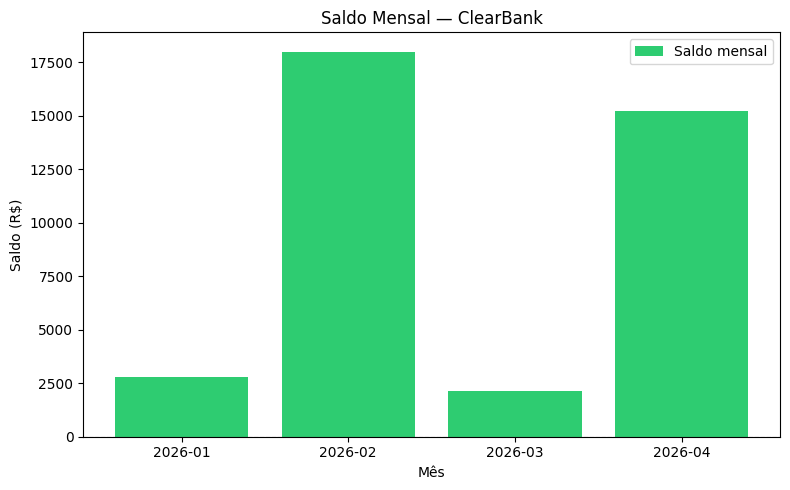

Gráfico salvo em grafico.png


In [11]:
import json

import matplotlib.pyplot as plt

with open(ARQUIVO_JSON, encoding="utf-8") as arquivo:
    dados_grafico = json.load(arquivo)

meses = sorted(dados_grafico["resumo_mensal"].keys())
saldos = [dados_grafico["resumo_mensal"][m]["saldo"] for m in meses]

plt.figure(figsize=(8, 5))
cores = ["#2ecc71" if s >= 0 else "#e74c3c" for s in saldos]
plt.bar(meses, saldos, color=cores, label="Saldo mensal")
plt.title("Saldo Mensal — ClearBank")
plt.xlabel("Mês")
plt.ylabel("Saldo (R$)")
plt.axhline(y=0, color="gray", linestyle="--", linewidth=0.8)
plt.legend()
plt.tight_layout()
plt.savefig("grafico.png", dpi=100)
plt.show()
print("Gráfico salvo em grafico.png")